In [34]:
import sys
sys.path.insert(0, "..")

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch

from src.data import load_concrete
from src.models import make_gp, train_mlp
from src.methods import mc_dropout_predict, train_ensemble, ensemble_predict, laplace_ll_predict, train_vi, vi_predict
from src.plotting import plot_sorted_predictions, plot_predicted_vs_true
from src.metrics import summary

np.random.seed(42)
torch.manual_seed(42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data

In [35]:
X_train, y_train, X_test, y_test, _ = load_concrete()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (824, 8), Test: (206, 8)


## Gaussian Process

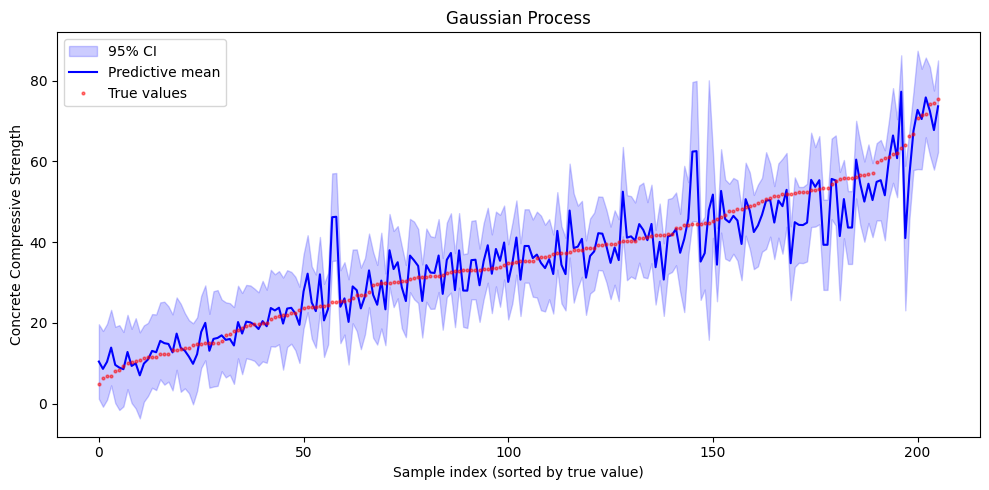

In [36]:
gp = make_gp().fit(X_train, y_train)
gp_mean, gp_std = gp.predict(X_test, return_std=True)
plot_sorted_predictions(y_test, gp_mean, gp_std, "Gaussian Process", "Concrete Compressive Strength")

## Monte Carlo Dropout
Gal & Ghahramani 2016.

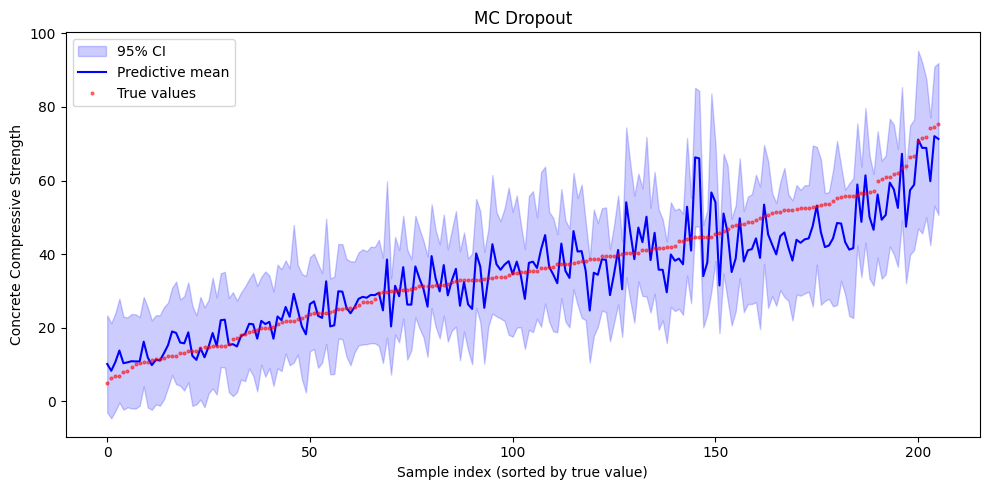

In [37]:
nn_dropout = train_mlp(X_train, y_train, dropout=0.2, epochs=1000)
mc_mean, mc_std = mc_dropout_predict(nn_dropout, X_test, n_samples=200)
plot_sorted_predictions(y_test, mc_mean, mc_std, "MC Dropout", "Concrete Compressive Strength")

## Deep Ensemble
Lakshminarayanan et al. 2017.

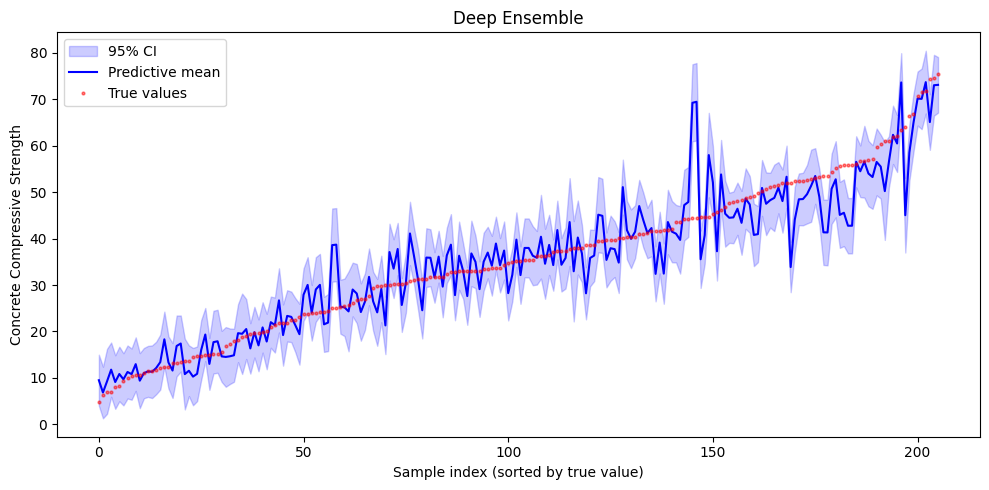

In [38]:
ensemble = train_ensemble(X_train, y_train, n_models=5, epochs=1000)
ens_mean, ens_std = ensemble_predict(ensemble, X_test)
plot_sorted_predictions(y_test, ens_mean, ens_std, "Deep Ensemble", "Concrete Compressive Strength")

## Laplace Approximation

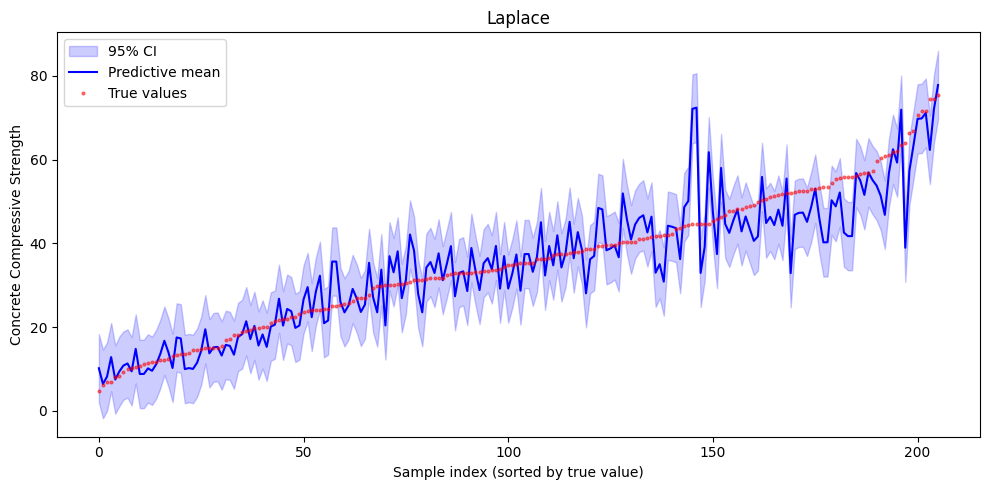

In [39]:
nn = train_mlp(X_train, y_train, epochs=1000)

la_ll_mean, la_ll_std = laplace_ll_predict(nn, X_train, y_train, X_test)
plot_sorted_predictions(y_test, la_ll_mean, la_ll_std, "Laplace", "Concrete Compressive Strength")

## Variational Inference
Bayes by Backprop (Blundell et al. 2015).

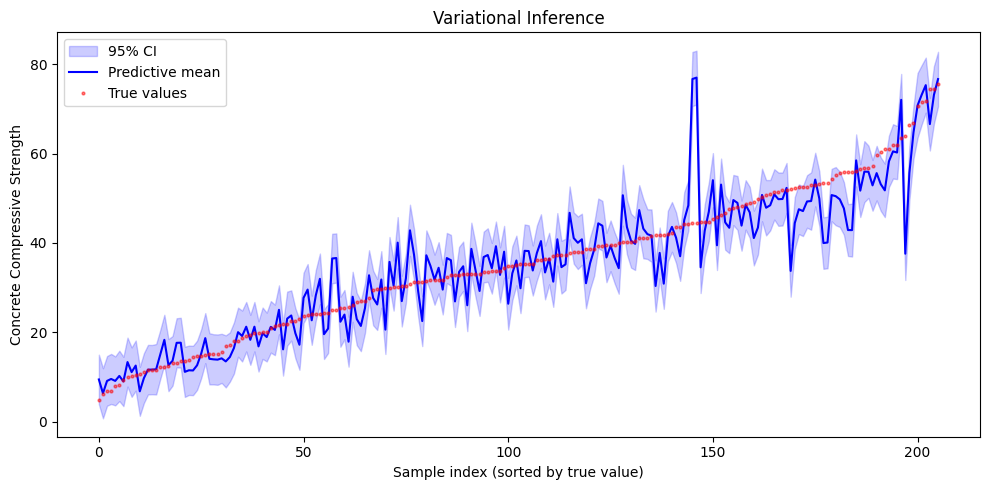

In [40]:
vi_model = train_vi(X_train, y_train, epochs=1000)
vi_mean, vi_std = vi_predict(vi_model, X_test, n_samples=200)
plot_sorted_predictions(y_test, vi_mean, vi_std, "Variational Inference", "Concrete Compressive Strength")

## Predicted vs True

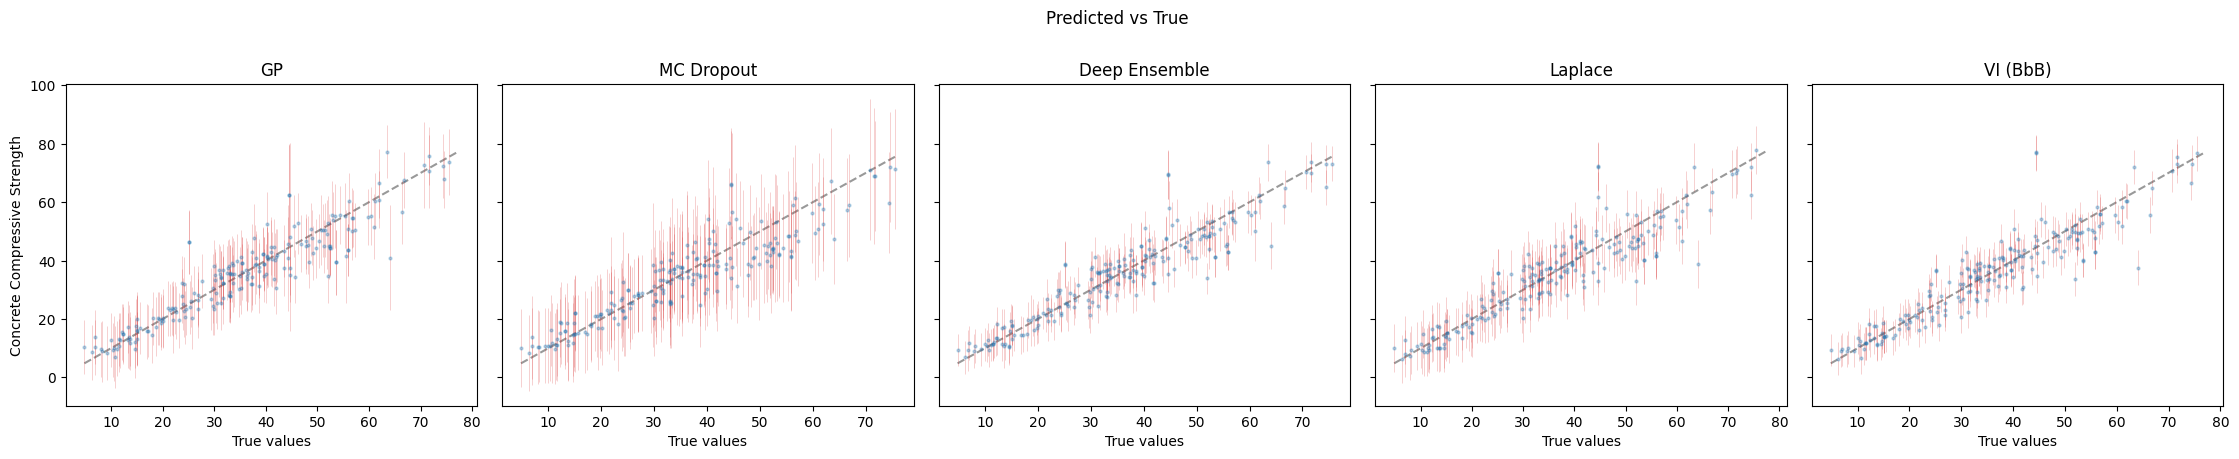

In [41]:
plot_predicted_vs_true(
    y_test,
    means  = [gp_mean,  mc_mean,  ens_mean, la_ll_mean, vi_mean],
    stds   = [gp_std,   mc_std,   ens_std,  la_ll_std,  vi_std],
    titles = ["GP", "MC Dropout", "Deep Ensemble", "Laplace", "VI (BbB)"],
    ylabel = "Concrete Compressive Strength",
)

## Metrics

In [42]:
results = {
    "GP":            summary(y_test, gp_mean,    gp_std),
    "MC Dropout":    summary(y_test, mc_mean,    mc_std),
    "Deep Ensemble": summary(y_test, ens_mean,   ens_std),
    "Laplace":       summary(y_test, la_ll_mean, la_ll_std),
    "VI (BbB)":      summary(y_test, vi_mean,    vi_std),
}
pd.DataFrame(results).T.round(4)

,RMSE,MAE,NLL,PICP,MPIW
GP,5.7542,4.0357,3.1085,0.9320,20.0597
MC Dropout,6.4856,5.0249,3.2742,0.9806,30.0204
Deep Ensemble,5.6172,3.9483,3.4121,0.8252,12.7909
Laplace,6.4106,4.5884,3.5234,0.8544,16.3596
VI (BbB),6.1285,4.1136,4.1082,0.7718,11.5447
